> **Nota:** A partir deste commit, os resultados refletem as duas correções de vazamento documentadas no projeto: corte temporal nas features de atributo (`spec/features_temporal_cutoff.md`) e holdout mensagem/supervisão nas arestas de treino (`spec/message_supervision_split.md`). Correspondem à linha "final" da seção 8 da spec do holdout. O baseline com os dois vazamentos está preservado em `data/results/results_v1_leaky.csv`.


# 03 — Modelos de ML Supervisionado

Treina e avalia dois classificadores binários para predição de links:
- **Random Forest** (`sklearn.ensemble.RandomForestClassifier`)
- **XGBoost** (`xgboost.XGBClassifier`)

Pipeline em três etapas:

| Etapa | O que faz | Conjunto usado |
|---|---|---|
| 1. Baseline | Modelos com hiperparâmetros padrão | Validação (avaliação) |
| 2. Tuning | Busca de hiperparâmetros via `PredefinedSplit` | Treino (fit) → Validação (score) |
| 3. Teste final | Avaliação única com params travados | Teste |

> **Sobre o split de tuning:** usamos `PredefinedSplit` do sklearn, que define exatamente um fold: o modelo é treinado no conjunto de treino e pontuado no de validação. Isso respeita a separação temporal — sem CV aleatório dentro do treino.

In [34]:
# !pip install xgboost shap

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBClassifier
import shap

FEATURES_DIR = Path("../data/features")
HEUR_DIR     = Path("../data/results/heuristics")

FEATURE_COLS = [
    "common_neighbors", "jaccard", "adamic_adar",
    "degree_u", "degree_v", "preferential_attachment",
    "h_index_sum", "h_index_diff",
    "citations_sum", "citations_diff",
    "area_jaccard",
]

/home/lipecorradini/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
train_df = pd.read_csv(FEATURES_DIR / "train_features.csv")
val_df   = pd.read_csv(FEATURES_DIR / "val_features.csv")
test_df  = pd.read_csv(FEATURES_DIR / "test_features.csv")

# node_u e node_v são identificadores, não features
X_train, y_train = train_df[FEATURE_COLS].values, train_df["label"].values
X_val,   y_val   = val_df[FEATURE_COLS].values,   val_df["label"].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df["label"].values

print(f"Treino : {X_train.shape}  |  pos: {y_train.sum():,}  neg: {(1-y_train).sum():,}")
print(f"Val    : {X_val.shape}    |  pos: {y_val.sum():,}    neg: {(1-y_val).sum():,}")
print(f"Teste  : {X_test.shape}   |  pos: {y_test.sum():,}   neg: {(1-y_test).sum():,}")

Treino : (115470, 11)  |  pos: 57,735  neg: 57,735
Val    : (6284, 11)    |  pos: 3,142    neg: 3,142
Teste  : (4846, 11)   |  pos: 2,423   neg: 2,423


In [37]:
def plotar_confusion(model, X, y, titulo, ax):
    """Confusion matrix normalizada por linha (% do total real de cada classe)."""
    pred      = model.predict(X)
    proba     = model.predict_proba(X)[:, 1]
    auc_score = roc_auc_score(y, proba)
    cm_norm   = confusion_matrix(y, pred, normalize="true")
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Negativo", "Positivo"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".1%")
    ax.set_title(f"{titulo}\nAUC = {auc_score:.4f}", fontsize=10)
    return auc_score


def plotar_roc(pares_modelo_label, X, y, titulo):
    fig, ax = plt.subplots(figsize=(5, 4))
    for model, label in pares_modelo_label:
        proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, proba)
        ax.plot(fpr, tpr, label=f"{label} (AUC = {auc(fpr, tpr):.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Aleatório")
    ax.set_xlabel("FPR (Taxa de Falsos Positivos)")
    ax.set_ylabel("TPR (Taxa de Verdadeiros Positivos)")
    ax.set_title(titulo)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## Etapa 1 — Baseline (hiperparâmetros padrão)

Ambos os modelos treinados com configurações padrão para estabelecer um piso de desempenho.
A métrica principal é **AUC-ROC** — padrão na literatura de predição de links (Liben-Nowell & Kleinberg, 2007).

As matrizes de confusão exibem percentuais normalizados por linha (recall por classe).

In [38]:
t = time.time()
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
print(f"RF     treinado em {time.time()-t:.1f}s")

t = time.time()
xgb_base = XGBClassifier(
    n_estimators=100, random_state=42,
    verbosity=0, eval_metric="logloss",
)
xgb_base.fit(X_train, y_train)
print(f"XGBoost treinado em {time.time()-t:.1f}s")

RF     treinado em 4.5s
XGBoost treinado em 1.5s


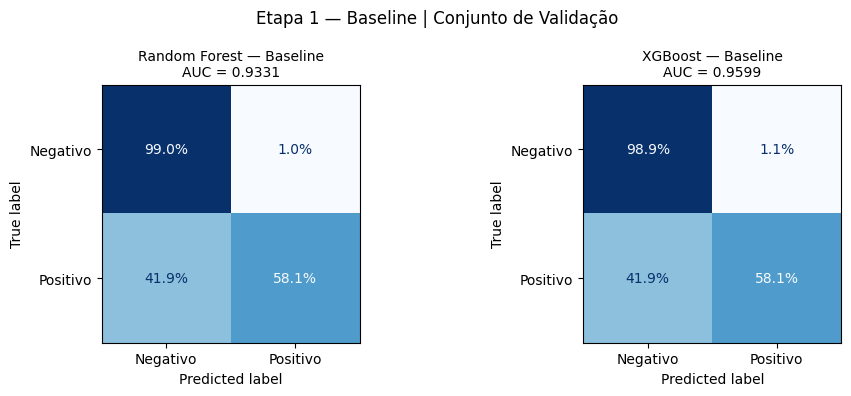

AUC val — RF      baseline : 0.9331
AUC val — XGBoost baseline : 0.9599


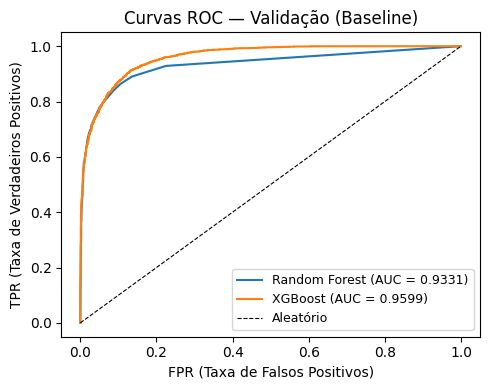

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
auc_rf_base  = plotar_confusion(rf_base,  X_val, y_val, "Random Forest — Baseline", axes[0])
auc_xgb_base = plotar_confusion(xgb_base, X_val, y_val, "XGBoost — Baseline",       axes[1])
fig.suptitle("Etapa 1 — Baseline | Conjunto de Validação", fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUC val — RF      baseline : {auc_rf_base:.4f}")
print(f"AUC val — XGBoost baseline : {auc_xgb_base:.4f}")

plotar_roc(
    [(rf_base, "Random Forest"), (xgb_base, "XGBoost")],
    X_val, y_val,
    "Curvas ROC — Validação (Baseline)"
)

## Etapa 2 — Tuning de hiperparâmetros

`PredefinedSplit` define exatamente um fold de CV:
- Índices com valor `-1` → treino
- Índices com valor `0` → validação (único fold de avaliação)

O `GridSearchCV` usa `scoring='roc_auc'` como função objetivo. Com `refit=False`, o `best_estimator_` não é re-treinado sobre train+val — os modelos finais são treinados manualmente sobre `X_train` apenas, garantindo que a avaliação de validação e teste permaneça válida.

In [40]:
X_search = np.vstack([X_train, X_val])
y_search = np.concatenate([y_train, y_val])

fold_ids = np.concatenate([
    np.full(len(X_train), -1, dtype=int),
    np.zeros(len(X_val),      dtype=int),
])
ps = PredefinedSplit(fold_ids)

print(f"X_search: {X_search.shape}")
print(f"  Treino no split : {(fold_ids == -1).sum():,} amostras")
print(f"  Val    no split : {(fold_ids ==  0).sum():,} amostras")

X_search: (121754, 11)
  Treino no split : 115,470 amostras
  Val    no split : 6,284 amostras


In [41]:
rf_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 15, 25],
    "min_samples_split": [2, 5, 10],
}
# 3×3×3 = 27 combinações, 1 fold cada → 27 fits
rf_gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_grid,
    cv=ps,
    scoring="roc_auc",
    refit=False,
    n_jobs=1,
    verbose=1,
)
t = time.time()
rf_gs.fit(X_search, y_search)
print(f"Busca concluída em {time.time()-t:.1f}s")
print(f"Melhores params RF : {rf_gs.best_params_}")
print(f"Melhor AUC val RF  : {rf_gs.best_score_:.4f}")

Fitting 1 folds for each of 27 candidates, totalling 27 fits
Busca concluída em 203.4s
Melhores params RF : {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Melhor AUC val RF  : 0.9556


In [42]:
xgb_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample":     [0.8, 1.0],
}
# 3×3×3×2 = 54 combinações, 1 fold cada → 54 fits
xgb_gs = GridSearchCV(
    estimator=XGBClassifier(random_state=42, verbosity=0, eval_metric="logloss"),
    param_grid=xgb_grid,
    cv=ps,
    scoring="roc_auc",
    refit=False,
    n_jobs=-1,
    verbose=1,
)
t = time.time()
xgb_gs.fit(X_search, y_search)
print(f"Busca concluída em {time.time()-t:.1f}s")
print(f"Melhores params XGBoost : {xgb_gs.best_params_}")
print(f"Melhor AUC val XGBoost  : {xgb_gs.best_score_:.4f}")

Fitting 1 folds for each of 54 candidates, totalling 54 fits
Busca concluída em 26.5s
Melhores params XGBoost : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Melhor AUC val XGBoost  : 0.9652


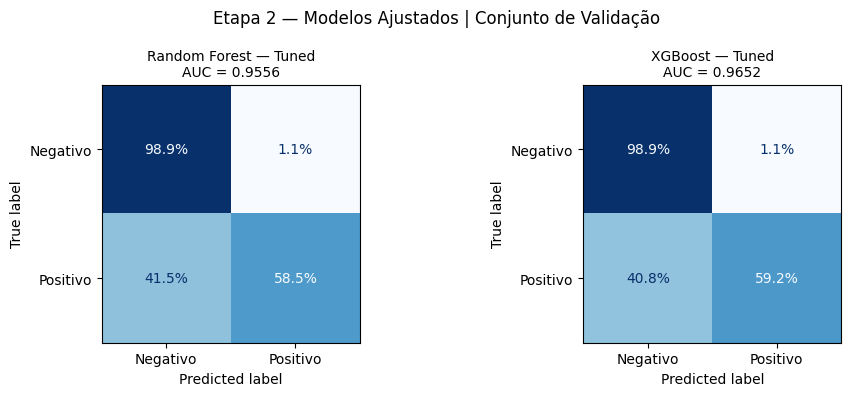

AUC val — RF      tuned : 0.9556
AUC val — XGBoost tuned : 0.9652


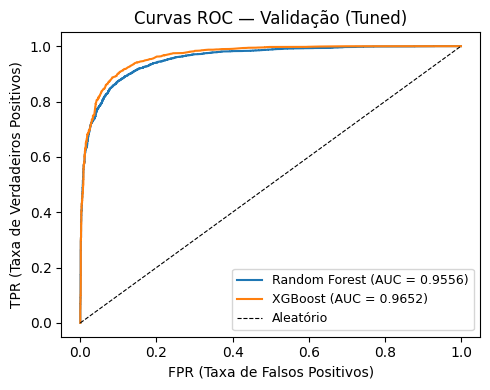

In [43]:
# Treinar modelos finais com os melhores params — apenas sobre X_train
rf_best = RandomForestClassifier(**rf_gs.best_params_, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)

xgb_best = XGBClassifier(**xgb_gs.best_params_, random_state=42, verbosity=0, eval_metric="logloss")
xgb_best.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
auc_rf_tuned  = plotar_confusion(rf_best,  X_val, y_val, "Random Forest — Tuned", axes[0])
auc_xgb_tuned = plotar_confusion(xgb_best, X_val, y_val, "XGBoost — Tuned",       axes[1])
fig.suptitle("Etapa 2 — Modelos Ajustados | Conjunto de Validação", fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUC val — RF      tuned : {auc_rf_tuned:.4f}")
print(f"AUC val — XGBoost tuned : {auc_xgb_tuned:.4f}")

plotar_roc(
    [(rf_best, "Random Forest"), (xgb_best, "XGBoost")],
    X_val, y_val,
    "Curvas ROC — Validação (Tuned)"
)

In [53]:
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

RESULTS_DIR = Path("../data/results")


def metricas(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "AUC-ROC":  roc_auc_score(y_true, proba),
        "Avg Prec": average_precision_score(y_true, proba),
        "F1":       f1_score(y_true, pred),
        "Precision":precision_score(y_true, pred),
        "Recall":   recall_score(y_true, pred),
    }

rows = []

# Heurísticas (carregadas do disco)
for metodo in ["common_neighbors", "jaccard", "adamic_adar", "katz"]:
    for split, y_true in [("val", y_val), ("test", y_test)]:
        df_h = pd.read_csv(HEUR_DIR / f"{metodo}_{split}.csv")
        rows.append({"Método": metodo, "Split": split,
                    **metricas(df_h["label"].values, df_h["score"].values)})

# Modelos ML (em memória)
for model, nome in [(rf_best, "random_forest"), (xgb_best, "xgboost")]:
    for split, X, y_true in [("val", X_val, y_val), ("test", X_test, y_test)]:
        proba = model.predict_proba(X)[:, 1]
        rows.append({"Método": nome, "Split": split, **metricas(y_true,
proba)})

df_results = (
    pd.DataFrame(rows)
    .sort_values(["Split", "AUC-ROC"], ascending=[True, False])
    .reset_index(drop=True)
)

for col in ["AUC-ROC", "Avg Prec", "F1", "Precision", "Recall"]:
    df_results[col] = df_results[col].map("{:.4f}".format)

path = RESULTS_DIR / f"results.csv"
df_results.to_csv(path, index=False)
print(f"Salvo: {path}  ({len(df_results)} linhas)")

print(df_results.to_string(index=False))


Salvo: ../data/results/results.csv  (12 linhas)
          Método Split AUC-ROC Avg Prec     F1 Precision Recall
         xgboost  test  0.9591   0.9575 0.7148    0.9764 0.5638
   random_forest  test  0.9466   0.9476 0.7077    0.9775 0.5547
            katz  test  0.9142   0.9183 0.0000    0.0000 0.0000
     adamic_adar  test  0.8105   0.8113 0.5676    0.9897 0.3979
common_neighbors  test  0.8104   0.8087 0.7669    0.9685 0.6348
         jaccard  test  0.8085   0.8050 0.0049    1.0000 0.0025
         xgboost   val  0.9652   0.9636 0.7387    0.9820 0.5920
   random_forest   val  0.9556   0.9574 0.7331    0.9808 0.5853
            katz   val  0.9172   0.9197 0.0000    0.0000 0.0000
     adamic_adar   val  0.8223   0.8213 0.5997    0.9876 0.4306
common_neighbors   val  0.8217   0.8186 0.7842    0.9749 0.6560
         jaccard   val  0.8211   0.8182 0.0070    1.0000 0.0035


/home/lipecorradini/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/lipecorradini/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Etapa 3 — Avaliação final no teste

Os modelos são avaliados no conjunto de teste **uma única vez**, com os hiperparâmetros definidos na etapa anterior.
Nenhuma decisão metodológica é tomada com base nos resultados abaixo.

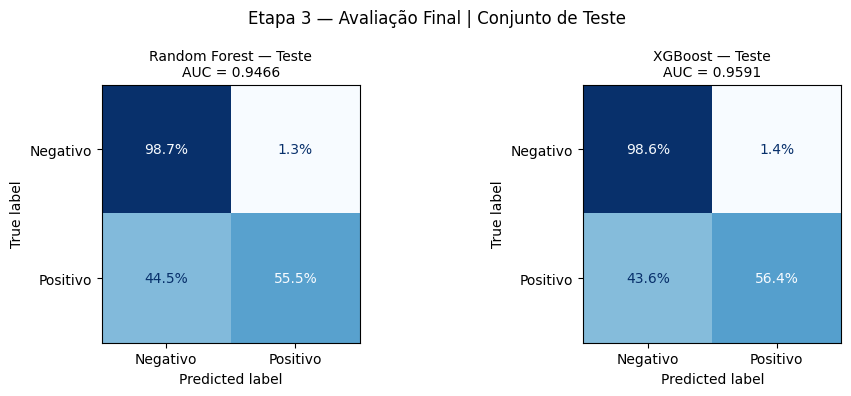

AUC teste — RF      : 0.9466
AUC teste — XGBoost : 0.9591


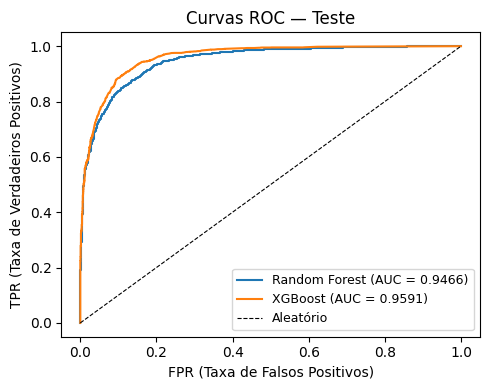

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
auc_rf_test  = plotar_confusion(rf_best,  X_test, y_test, "Random Forest — Teste", axes[0])
auc_xgb_test = plotar_confusion(xgb_best, X_test, y_test, "XGBoost — Teste",       axes[1])
fig.suptitle("Etapa 3 — Avaliação Final | Conjunto de Teste", fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUC teste — RF      : {auc_rf_test:.4f}")
print(f"AUC teste — XGBoost : {auc_xgb_test:.4f}")

plotar_roc(
    [(rf_best, "Random Forest"), (xgb_best, "XGBoost")],
    X_test, y_test,
    "Curvas ROC — Teste"
)

## Comparação com heurísticas

Resultados das heurísticas carregados de `data/results/heuristics/` (computados em `01_heuristics.ipynb`).

In [45]:
def auc_heuristica(metodo, split):
    df = pd.read_csv(HEUR_DIR / f"{metodo}_{split}.csv")
    return roc_auc_score(df["label"], df["score"])

heuristicas = ["common_neighbors", "jaccard", "adamic_adar", "katz"]
resultados  = []

for h in heuristicas:
    resultados.append({
        "Método":        h,
        "AUC Validação": auc_heuristica(h, "val"),
        "AUC Teste":     auc_heuristica(h, "test"),
    })

resultados.append({"Método": "Random Forest", "AUC Validação": auc_rf_tuned,  "AUC Teste": auc_rf_test})
resultados.append({"Método": "XGBoost",       "AUC Validação": auc_xgb_tuned, "AUC Teste": auc_xgb_test})

df_res = (
    pd.DataFrame(resultados)
    .sort_values("AUC Teste", ascending=False)
    .reset_index(drop=True)
)
df_res["AUC Validação"] = df_res["AUC Validação"].map("{:.4f}".format)
df_res["AUC Teste"]     = df_res["AUC Teste"].map("{:.4f}".format)
print(df_res.to_string(index=False))

          Método AUC Validação AUC Teste
         XGBoost        0.9652    0.9591
   Random Forest        0.9556    0.9466
            katz        0.9172    0.9142
     adamic_adar        0.8223    0.8105
common_neighbors        0.8217    0.8104
         jaccard        0.8211    0.8085


## Importância das Features

### 5.1 Importância intrínseca (mean decrease in impurity)

Calculada a partir das estruturas internas dos modelos:
- **Random Forest**: média da redução de impureza de Gini por feature, acumulada sobre todas as árvores
- **XGBoost**: ganho total de cada feature ao longo de todos os splits do ensemble

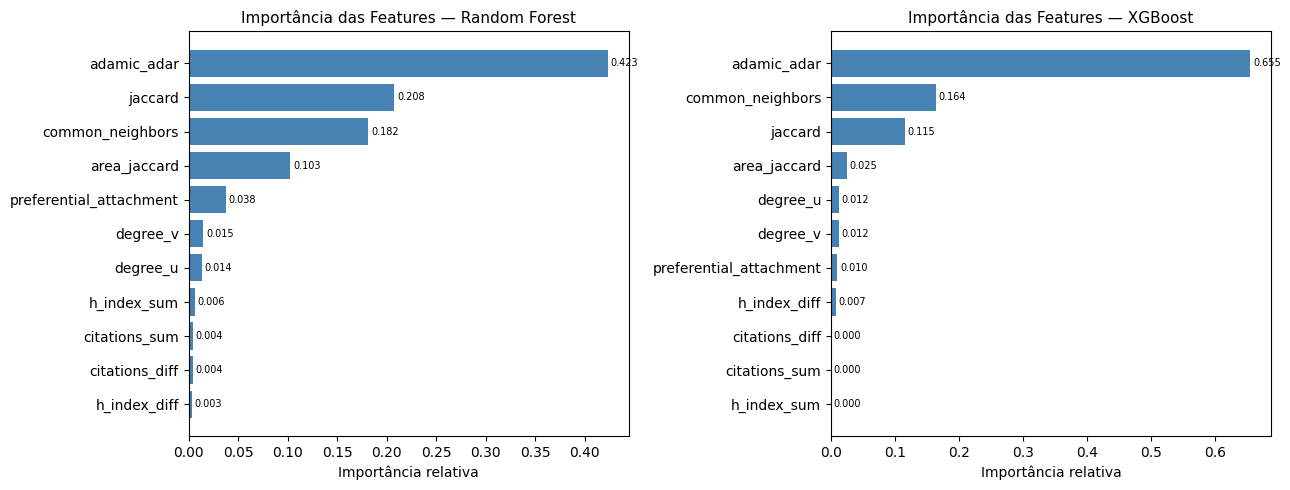

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, nome in [
    (axes[0], rf_best,  "Random Forest"),
    (axes[1], xgb_best, "XGBoost"),
]:
    importances = model.feature_importances_
    idx  = np.argsort(importances)
    bars = ax.barh(
        [FEATURE_COLS[i] for i in idx],
        importances[idx],
        color="steelblue",
    )
    ax.set_title(f"Importância das Features — {nome}", fontsize=11)
    ax.set_xlabel("Importância relativa")
    ax.bar_label(bars, fmt="{:.3f}", padding=2, fontsize=7)

plt.tight_layout()
plt.show()